# Closed-Loop Two-Session Walkthrough

This notebook inspects two Kilosort result folders produced by the quick closed-loop workflow.
It is designed to work well with short validation runs such as `tmax=100s`.

## Configure Result Paths

Set `session1_results_dir` and `session2_results_dir` to the two result folders you want to compare.
Session 2 should contain the closed-loop outputs generated with `closed_loop_identity_mode="preserve"`.

In [15]:
from pathlib import Path
import csv
import json

import matplotlib.pyplot as plt
import numpy as np

session1_results_dir = Path('/home/fye/Documents/30_ClosedLoop/Exp/251231B05/20260409/ExpData/KilosortClosedLoop/20260409_251231B05_clv/ProbeE/run_01/recording1')
session2_results_dir = Path('/home/fye/Documents/30_ClosedLoop/Exp/251231B05/20260409/ExpData/KilosortClosedLoop/20260409_251231B05_clv/ProbeE/run_01/recording2')

In [16]:
def load_prior_bundle(results_dir):
    bundle = np.load(results_dir / 'prior_bundle.npz', allow_pickle=True)
    metadata = bundle['metadata_json']
    if isinstance(metadata, np.ndarray):
        metadata = metadata.item()
    return {k: bundle[k] for k in bundle.files if k != 'metadata_json'}, json.loads(str(metadata))


def load_map_rows(results_dir):
    rows = []
    with open(results_dir / 'cross_loop_unit_map.csv', newline='') as f:
        for row in csv.DictReader(f):
            rows.append(row)
    return rows


def load_summary(results_dir):
    with open(results_dir / 'cross_loop_summary.json') as f:
        return json.load(f)


def load_debug(results_dir):
    return np.load(results_dir / 'cross_loop_debug.npz', allow_pickle=True)


bundle1, meta1 = load_prior_bundle(session1_results_dir)
bundle2, meta2 = load_prior_bundle(session2_results_dir)
map_rows = load_map_rows(session2_results_dir)
summary2 = load_summary(session2_results_dir)
debug2 = load_debug(session2_results_dir)

print('session1 loop index:', meta1.get('loop_index'))
print('session2 loop index:', meta2.get('loop_index'))
print('session2 summary:')
print(json.dumps(summary2, indent=2))

session1 loop index: 0
session2 loop index: 1
session2 summary:
{
  "enabled": true,
  "loop_index": 1,
  "rigid_shift_um": 5.0,
  "alignment_mode_requested": "nonrigid",
  "alignment_mode_used": "rigid",
  "alignment_fallback_reason": "insufficient_score_gain",
  "rigid_score": 0.719947338104248,
  "nonrigid_score": 0.4931944012641907,
  "nonrigid_score_gain": -0.22675293684005737,
  "nonrigid_accepted": false,
  "n_carried": 58,
  "n_new": 199,
  "n_stale": 164,
  "n_matching_candidates": 58,
  "prior_path": "/home/fye/Documents/30_ClosedLoop/Exp/251231B05/20260409/ExpData/KilosortClosedLoop/20260409_251231B05_clv/ProbeE/run_01/recording1/prior_bundle.npz"
}


## Quick Validation Snapshot

In [17]:
status_counts = {}
for row in map_rows:
    status_counts[row['status']] = status_counts.get(row['status'], 0) + 1

print('Map row counts by status:', status_counts)
print('Session 2 alignment requested:', summary2.get('alignment_mode_requested', 'rigid'))
print('Session 2 alignment used:', summary2.get('alignment_mode_used', 'rigid'))
print('Rigid score:', summary2.get('rigid_score'))
print('Nonrigid score:', summary2.get('nonrigid_score'))
print('Fallback reason:', summary2.get('alignment_fallback_reason', ''))

Map row counts by status: {'carried': 58, 'new': 199, 'stale': 164}
Session 2 alignment requested: nonrigid
Session 2 alignment used: rigid
Rigid score: 0.719947338104248
Nonrigid score: 0.4931944012641907
Fallback reason: insufficient_score_gain


## Fingerprint Alignment Diagnostic

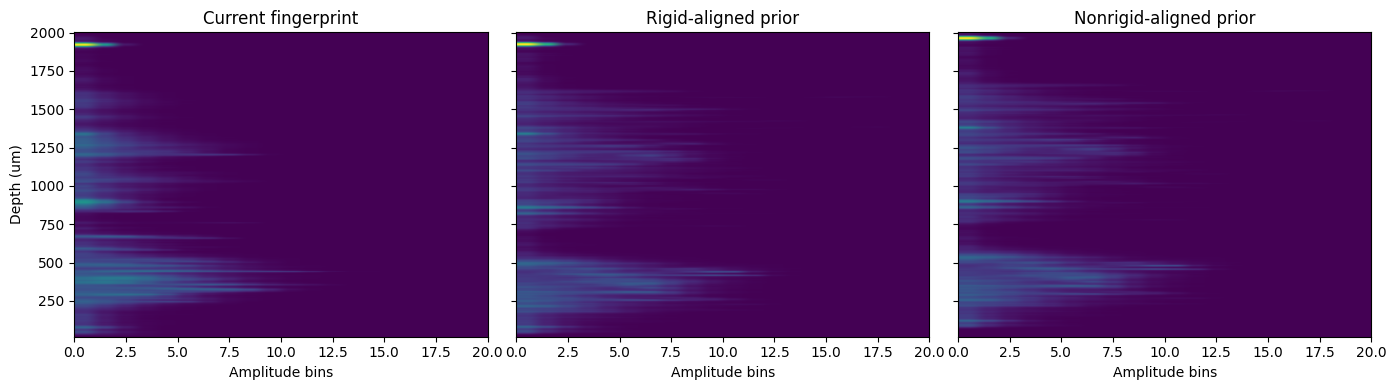

In [18]:
depths = debug2['current_fingerprint_depths']
current_fp = debug2['current_fingerprint']
rigid_fp = debug2['aligned_rigid_fingerprint'] if 'aligned_rigid_fingerprint' in debug2.files else debug2['aligned_prior_fingerprint']
nonrigid_fp = debug2['aligned_nonrigid_fingerprint'] if 'aligned_nonrigid_fingerprint' in debug2.files else rigid_fp

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
axes[0].imshow(current_fp, aspect='auto', origin='lower', extent=[0, current_fp.shape[1], depths.min(), depths.max()])
axes[0].set_title('Current fingerprint')
axes[1].imshow(rigid_fp, aspect='auto', origin='lower', extent=[0, rigid_fp.shape[1], depths.min(), depths.max()])
axes[1].set_title('Rigid-aligned prior')
axes[2].imshow(nonrigid_fp, aspect='auto', origin='lower', extent=[0, nonrigid_fp.shape[1], depths.min(), depths.max()])
axes[2].set_title('Nonrigid-aligned prior')
for ax in axes:
    ax.set_xlabel('Amplitude bins')
axes[0].set_ylabel('Depth (um)')
plt.tight_layout()

## Alignment Score Comparison

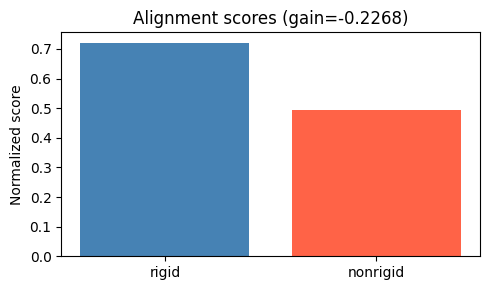

In [19]:
rigid_score = float(np.atleast_1d(debug2['rigid_score'])[0]) if 'rigid_score' in debug2.files else summary2.get('rigid_score', np.nan)
nonrigid_score = float(np.atleast_1d(debug2['nonrigid_score'])[0]) if 'nonrigid_score' in debug2.files else summary2.get('nonrigid_score', np.nan)
score_gain = float(np.atleast_1d(debug2['nonrigid_score_gain'])[0]) if 'nonrigid_score_gain' in debug2.files else summary2.get('nonrigid_score_gain', np.nan)

plt.figure(figsize=(5, 3))
plt.bar(['rigid', 'nonrigid'], [rigid_score, nonrigid_score], color=['steelblue', 'tomato'])
plt.title(f'Alignment scores (gain={score_gain:.4f})')
plt.ylabel('Normalized score')
plt.tight_layout()

## Non-Rigid Shift Field

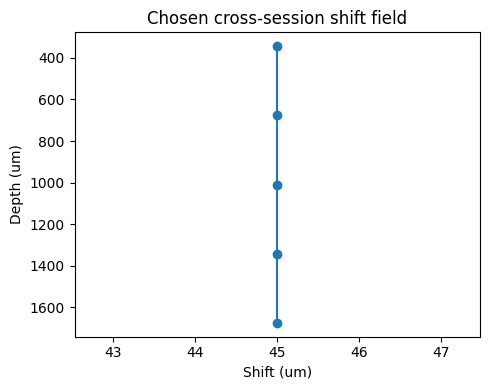

In [20]:
block_depths = debug2['nonrigid_block_depths'] if 'nonrigid_block_depths' in debug2.files else np.zeros(0)
block_shifts = debug2['nonrigid_block_shifts_um'] if 'nonrigid_block_shifts_um' in debug2.files else np.zeros(0)

if block_depths.size:
    plt.figure(figsize=(5, 4))
    plt.plot(block_shifts, block_depths, marker='o')
    plt.gca().invert_yaxis()
    plt.xlabel('Shift (um)')
    plt.ylabel('Depth (um)')
    plt.title('Chosen cross-session shift field')
    plt.tight_layout()
else:
    print('No nonrigid block field saved for this run.')

## Carried And New Units

carried: 58
new: 199
stale: 164


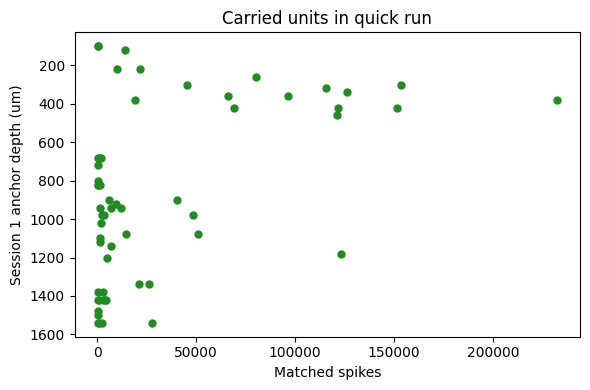

In [21]:
carried_rows = [row for row in map_rows if row['status'] == 'carried']
new_rows = [row for row in map_rows if row['status'] == 'new']
stale_rows = [row for row in map_rows if row['status'] == 'stale']

print('carried:', len(carried_rows))
print('new:', len(new_rows))
print('stale:', len(stale_rows))

def _to_float(value, default=np.nan):
    try:
        return float(value)
    except (TypeError, ValueError):
        return default

carried_ids = np.array([int(row['global_unit_id']) for row in carried_rows], dtype=np.int32) if carried_rows else np.zeros(0, dtype=np.int32)
carried_depth_lookup = {int(gid): float(depth) for gid, depth in zip(bundle1['global_unit_ids'], bundle1['anchor_y'])}
carried_depths = np.array([carried_depth_lookup.get(int(gid), np.nan) for gid in carried_ids], dtype=np.float32) if carried_rows else np.zeros(0, dtype=np.float32)
carried_counts = np.array([int(row['n_spikes_matched']) for row in carried_rows], dtype=np.int32) if carried_rows else np.zeros(0, dtype=np.int32)

if carried_rows:
    order = np.argsort(carried_depths)
    plt.figure(figsize=(6, 4))
    plt.scatter(carried_counts[order], carried_depths[order], c='forestgreen', s=25)
    plt.gca().invert_yaxis()
    plt.xlabel('Matched spikes')
    plt.ylabel('Session 1 anchor depth (um)')
    plt.title('Carried units in quick run')
    plt.tight_layout()
else:
    print('No carried units found in the session 2 map.')

## Template Similarity Vs Overlap

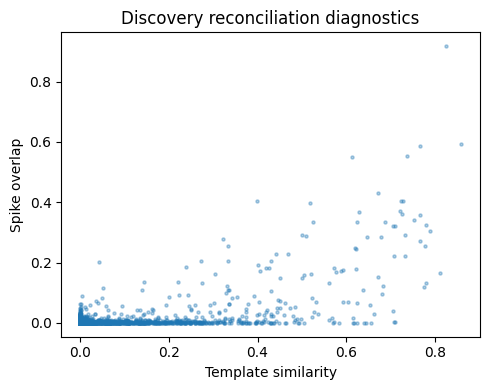

In [22]:
sim = debug2['template_similarity']
ov = debug2['template_overlap']

if sim.size and ov.size:
    plt.figure(figsize=(5, 4))
    plt.scatter(sim.ravel(), ov.ravel(), s=5, alpha=0.35)
    plt.xlabel('Template similarity')
    plt.ylabel('Spike overlap')
    plt.title('Discovery reconciliation diagnostics')
    plt.tight_layout()
else:
    print('No template reconciliation arrays available.')